In [14]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

In [15]:
HIDDEN_LAYER_SIZE = 1000

class MalwareClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MalwareClassifier, self).__init__()
        self.resnet = models.resnet50(weights='DEFAULT')
        for param in self.resnet.parameters():
            param.requires_grad = False
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, HIDDEN_LAYER_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_SIZE, n_classes)
        )

    def forward(self, x):
        return self.resnet(x)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_CLASSES = 8  # adjust if your dataset has a different count

# ── Option A: TorchScript model saved with save_model() ──────────────────────
MODEL_PATH = "malware_classifier.pth"   # path to your saved model
model = torch.jit.load(MODEL_PATH, map_location=device)

# ── Option B: plain state-dict (uncomment if you used torch.save(model.state_dict()))
# model = MalwareClassifier(N_CLASSES)
# model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model.eval().to(device)
print(f"Model loaded on {device}")

Model loaded on cuda


In [19]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder

DATA_PATH = r"C:\Users\lenovo LOQ\PFA2\Sorted"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = ImageFolder(os.path.join(DATA_PATH, "train"), transform=transform)

print("Class → index mapping:")
for cls, idx in sorted(dataset.class_to_idx.items(), key=lambda x: x[1]):
    print(f"  [{idx}] {cls}")

BENIGN_IDX   = dataset.class_to_idx["benign"]
SOURCE_IDX   = dataset.class_to_idx["worm"]
SOURCE_LABEL = "worm"

print(f"\nTarget (benign) index : {BENIGN_IDX}")
print(f"Source (worm)   index : {SOURCE_IDX}")

Class → index mapping:
  [0] adware
  [1] backdoor
  [2] benign
  [3] downloader
  [4] spyware
  [5] trojan
  [6] virus
  [7] worm

Target (benign) index : 2
Source (worm)   index : 7


In [20]:
test_dataset = ImageFolder(os.path.join(DATA_PATH, "test"), transform=transform)

worm_indices = [i for i, (_, lbl) in enumerate(test_dataset.samples) if lbl == SOURCE_IDX]
print(f"Found {len(worm_indices)} worm samples in test set.")

sample_idx = worm_indices[0]
img_tensor, true_label = test_dataset[sample_idx]
img_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(img_tensor)
    pred_clean = logits.argmax(dim=1).item()

print(f"True label  : {true_label} ({SOURCE_LABEL})")
print(f"Predicted   : {pred_clean} (correct={pred_clean == true_label})")

Found 136 worm samples in test set.
True label  : 7 (worm)
Predicted   : 7 (correct=True)


In [21]:
def pgd_targeted(
    model: nn.Module,
    x: torch.Tensor,          # clean input  (1, C, H, W), already on device
    target_class: int,         # index of Benign
    epsilon: float = 8/255,    # L∞ budget (normalised space)
    alpha: float = 2/255,      # step size
    n_iter: int = 40,          # PGD iterations
    random_start: bool = True  # randomise within ε-ball before iterating
) -> torch.Tensor:
    """
    Targeted PGD in normalised pixel space.
    Returns the adversarial example (same shape as x).
    """
    criterion = nn.CrossEntropyLoss()
    target = torch.tensor([target_class], device=x.device)

    x_adv = x.clone().detach()

    if random_start:
        # Uniform random init inside ε-ball
        noise = torch.empty_like(x_adv).uniform_(-epsilon, epsilon)
        x_adv = (x_adv + noise).detach()

    for step in range(n_iter):
        x_adv.requires_grad_(True)

        logits = model(x_adv)
        # Minimise CE of the TARGET class → push model toward Benign
        loss = criterion(logits, target)

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # Gradient descent (targeted) — MINUS sign
            x_adv = x_adv - alpha * x_adv.grad.sign()
            # Project onto L∞ ball centred at original x
            delta = torch.clamp(x_adv - x, min=-epsilon, max=epsilon)
            x_adv = (x + delta).detach()

        if (step + 1) % 10 == 0:
            with torch.no_grad():
                pred = model(x_adv).argmax(dim=1).item()
            print(f"  Step {step+1:3d}/{n_iter} | loss={loss.item():.4f} | pred={pred}",
                  "✓ SUCCESS" if pred == target_class else "")

    return x_adv

In [22]:
print("Running targeted PGD: worm → Benign ...")
x_adv = pgd_targeted(
    model,
    img_tensor,
    target_class=BENIGN_IDX,
    epsilon=8/255,
    alpha=2/255,
    n_iter=40,
    random_start=True
)

with torch.no_grad():
    logits_adv  = model(x_adv)
    pred_adv    = logits_adv.argmax(dim=1).item()
    confidence  = torch.softmax(logits_adv, dim=1)[0, BENIGN_IDX].item()

print(f"\nResult:")
print(f"  Clean prediction  : {pred_clean} ({SOURCE_LABEL})")
print(f"  Adversarial pred  : {pred_adv} ({'BENIGN ✓ ATTACK SUCCEEDED' if pred_adv == BENIGN_IDX else 'still malware'})")
print(f"  Benign confidence : {confidence*100:.2f}%")

Running targeted PGD: worm → Benign ...
  Step  10/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  20/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  30/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  40/40 | loss=0.0000 | pred=2 ✓ SUCCESS

Result:
  Clean prediction  : 7 (worm)
  Adversarial pred  : 2 (BENIGN ✓ ATTACK SUCCEEDED)
  Benign confidence : 100.00%


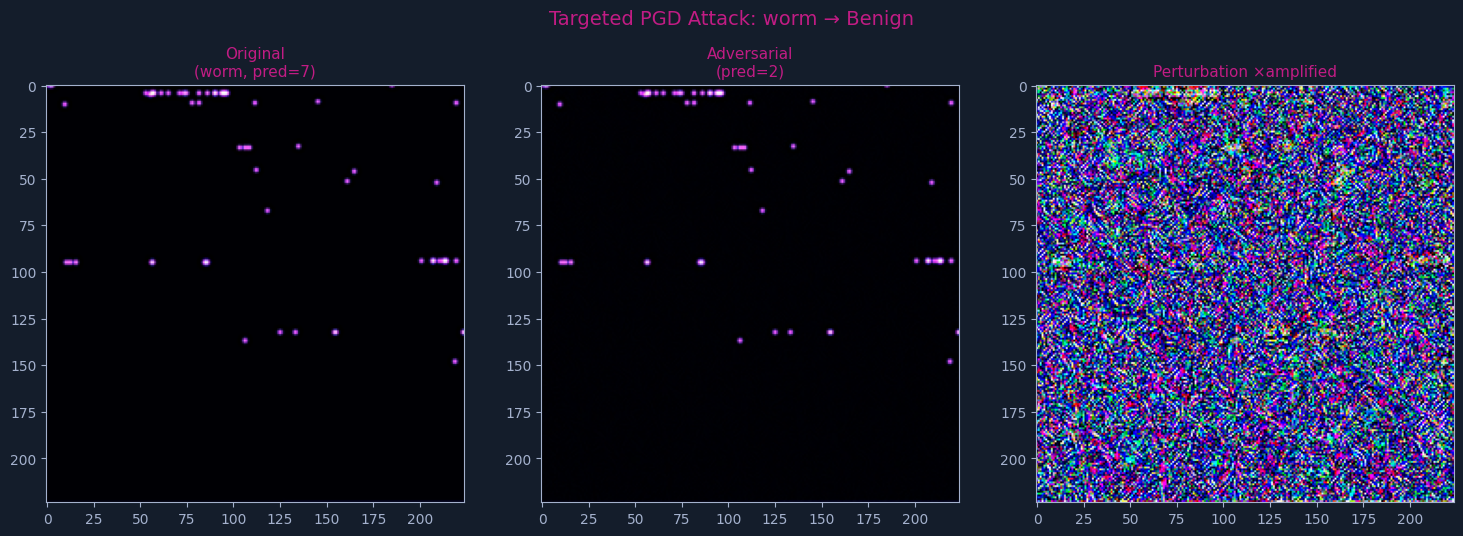

Saved → pgd_attack_result.png


In [23]:
def denorm(t, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Reverse ImageNet normalisation for display."""
    m = torch.tensor(mean, device=t.device).view(3,1,1)
    s = torch.tensor(std,  device=t.device).view(3,1,1)
    return (t * s + m).clamp(0, 1).cpu().permute(1, 2, 0).numpy()

clean_img = denorm(img_tensor.squeeze(0))
adv_img   = denorm(x_adv.squeeze(0))
delta_vis = np.abs(adv_img - clean_img)
delta_vis = delta_vis / delta_vis.max()  # stretch for visibility

pink       = "#C11C84"
node_black = "#141D2B"
hacker_grey= "#A4B1CD"

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=node_black)
titles = [f"Original\n(worm, pred={pred_clean})",
          f"Adversarial\n(pred={pred_adv})",
          "Perturbation ×amplified"]
imgs   = [clean_img, adv_img, delta_vis]

for ax, title, im in zip(axes, titles, imgs):
    ax.imshow(im)
    ax.set_title(title, color=pink, fontsize=11)
    ax.set_facecolor(node_black)
    ax.tick_params(colors=hacker_grey)
    for spine in ax.spines.values():
        spine.set_edgecolor(hacker_grey)

plt.suptitle("Targeted PGD Attack: worm → Benign", color=pink, fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("pgd_attack_result.png", dpi=150, bbox_inches='tight',
            facecolor=node_black)
plt.show()
print("Saved → pgd_attack_result.png")

In [24]:
successes = 0
total     = 0

for idx in worm_indices:
    x, lbl = test_dataset[idx]
    x = x.unsqueeze(0).to(device)

    x_adv_batch = pgd_targeted(
        model, x, BENIGN_IDX,
        epsilon=8/255, alpha=2/255, n_iter=40, random_start=True
    )
    with torch.no_grad():
        pred = model(x_adv_batch).argmax(dim=1).item()

    total += 1
    if pred == BENIGN_IDX:
        successes += 1

print(f"\nBatch Attack Results")
print(f"Samples attacked : {total}")
print(f"Success rate     : {successes}/{total} = {100*successes/total:.1f}%")

  Step  10/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  20/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  30/40 | loss=0.0002 | pred=2 ✓ SUCCESS
  Step  40/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  10/40 | loss=0.0003 | pred=2 ✓ SUCCESS
  Step  20/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  30/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  40/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  10/40 | loss=0.0001 | pred=2 ✓ SUCCESS
  Step  20/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  30/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  40/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  10/40 | loss=0.0004 | pred=2 ✓ SUCCESS
  Step  20/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  30/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  40/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  10/40 | loss=0.0005 | pred=2 ✓ SUCCESS
  Step  20/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  30/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  40/40 | loss=0.0000 | pred=2 ✓ SUCCESS
  Step  10/40 | loss=0.0001 | pred=2 ✓ SUCCESS
  Step  20/40